# Notebook 06 — Market Value Prediction

Train regression models to predict FIFA player market value.

## 1. Imports ##

In [9]:
from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.ensemble import RandomForestRegressor
import joblib

## 2. Directories ##

In [10]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 3. DuckDB Connection ##

In [11]:
con = duckdb.connect()

PARQUET = PROCESSED_DATA_DIR / "players_clean"

con.execute("PRAGMA threads=8")
con.execute("PRAGMA memory_limit='8GB'")

## 4. Build ML Dataset ##

In [12]:
ml = con.sql(f"""
SELECT

TRY_CAST(age AS DOUBLE) AS age,

TRY_CAST(overall AS DOUBLE) AS overall,

TRY_CAST(potential AS DOUBLE) AS potential,

TRY_CAST(pace AS DOUBLE) AS pace,

TRY_CAST(shooting AS DOUBLE) AS shooting,

TRY_CAST(passing AS DOUBLE) AS passing,

TRY_CAST(dribbling AS DOUBLE) AS dribbling,

TRY_CAST(defending AS DOUBLE) AS defending,

TRY_CAST(physic AS DOUBLE) AS physic,

TRY_CAST(wage_eur AS DOUBLE) AS wage,

TRY_CAST(value_eur AS DOUBLE) AS market_value

FROM parquet_scan('{PARQUET}')

WHERE

TRY_CAST(value_eur AS DOUBLE) IS NOT NULL

AND TRY_CAST(overall AS DOUBLE) IS NOT NULL

AND TRY_CAST(age AS DOUBLE) IS NOT NULL

USING SAMPLE 300000 ROWS
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 5. Missing Values ##

In [14]:
ml = ml.dropna()

ml.shape

(263025, 11)

## 6. Features ##

In [15]:
X = ml.drop(columns=["market_value"])

y = ml["market_value"]

## 7. Train / Test Split ##

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

## 8. Train Random Forest ##

In [17]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

## 9. Predictions ##

In [18]:
pred = model.predict(X_test)

## 10. Metrics ##

In [19]:
mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print(f"MAE : {mae:,.0f}")

print(f"RMSE: {rmse:,.0f}")

print(f"R²  : {r2:.4f}")

MAE : 262,004
RMSE: 996,244
R²  : 0.9701


## 11. Feature Importance ##

In [20]:
importance = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": model.feature_importances_,
    }
).sort_values(
    "importance",
    ascending=False,
)

importance

,feature,importance
1,overall,0.770930
2,potential,0.127031
0,age,0.026036
9,wage,0.014443
4,shooting,0.012350
7,defending,0.011553
3,pace,0.011071
6,dribbling,0.009445
8,physic,0.009433
5,passing,0.007709


## 12. Plot Importance ##

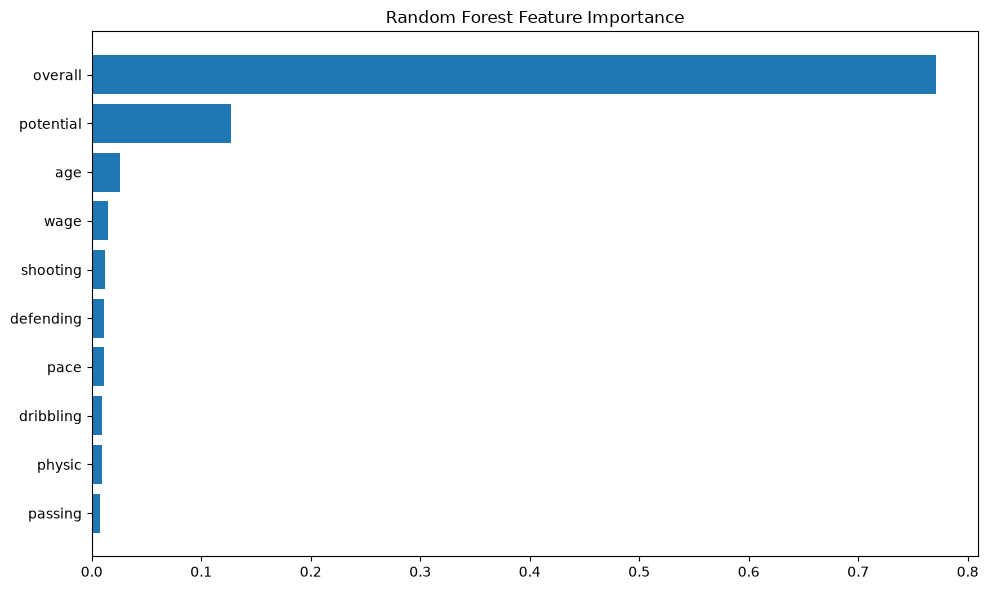

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"],
    importance["importance"],
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_importance.png",
    dpi=300,
)

plt.show()

plt.close()

## 13. Actual VS Predicted ##

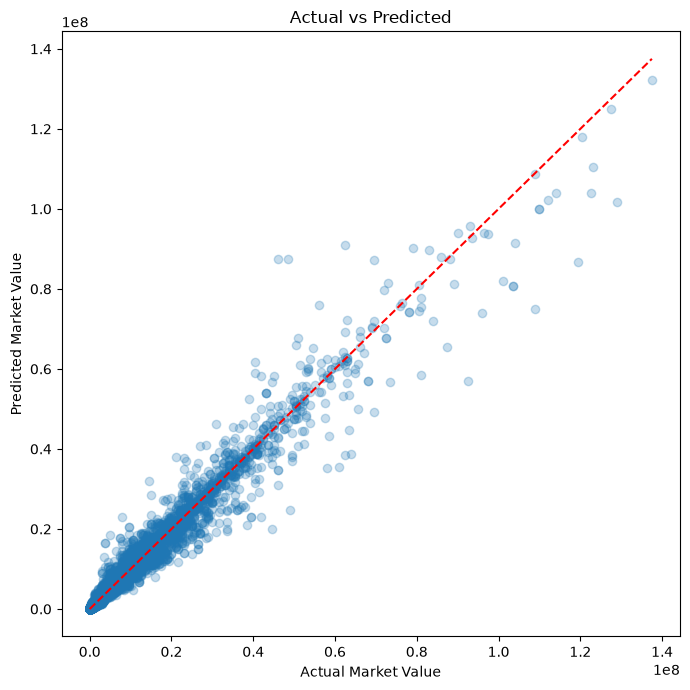

In [22]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    pred,
    alpha=0.25,
)

lims = [
    min(y_test.min(), pred.min()),
    max(y_test.max(), pred.max()),
]

plt.plot(lims, lims, "r--")

plt.xlabel("Actual Market Value")

plt.ylabel("Predicted Market Value")

plt.title("Actual vs Predicted")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "actual_vs_predicted.png",
    dpi=300,
)

plt.show()

plt.close()

## 14. Save Model ##

In [23]:
joblib.dump(
    model,
    MODELS_DIR / "random_forest_market_value.pkl",
)

['/Users/subhankarbiswas/fifa-player-analytics/models/random_forest_market_value.pkl']

## 15. Save Metrics ##

In [24]:
metrics = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2"],
        "Value": [mae, rmse, r2],
    }
)

metrics.to_csv(
    PROJECT_ROOT / "reports" / "tables" / "model_metrics.csv",
    index=False,
)

## Conclusions

- Compare model performance using MAE, RMSE, and R².
- Select the best-performing model.
- Save the trained models for downstream explainability.

### Next

Proceed to **Notebook 07 — Player Clustering**.